In [1]:
import pandas as pd
import numpy as np

file = 'kidney_disease.csv'
df = pd.read_csv(file)

print(df.head(5))


   id   age    bp     sg   al   su     rbc        pc         pcc          ba  \
0   0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2   2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3   3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4   4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

   ...  pcv    wc   rc  htn   dm  cad appet   pe  ane classification  
0  ...   44  7800  5.2  yes  yes   no  good   no   no            ckd  
1  ...   38  6000  NaN   no   no   no  good   no   no            ckd  
2  ...   31  7500  NaN   no  yes   no  poor   no  yes            ckd  
3  ...   32  6700  3.9  yes   no   no  poor  yes  yes            ckd  
4  ...   35  7300  4.6   no   no   no  good   no   no            ckd  

[5 rows x 26 columns]


DATA CLEANING AND PRE-PROCESSING PART 1: FIND MISSING VALUES

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [3]:
df.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

DATA CLEANING AND PRE-PROCESSING PART 2: CLEAN IRREGULAR VALUES

In [4]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df.replace({
    '\tno': 'no',
    '\tyes': 'yes',
    ' yes': 'yes',
    'ckd\t': 'ckd'
}, inplace=True)

DATA CLEANING AND PRE-PROCESSING PART 3: CONVERTING INTO A CORRECT FORMAT

In [5]:
df['wc'] = pd.to_numeric(df['wc'], errors='coerce')
df['rc'] = pd.to_numeric(df['rc'], errors='coerce')
df['pcv'] = pd.to_numeric(df['pcv'], errors='coerce')

DATA CLEANING AND PRE-PROCESSING PART 4: REMOVING NULL VALUES (REPLACED WITH RANDOM SAMPLING)

CATEGORICAL AND NUMERICAL COLUMN

In [6]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

In [7]:
def random_value_imputation(feature):
    random_sample = df[feature].dropna().sample(df[feature].isna().sum())
    random_sample.index = df[df[feature].isna()].index
    df.loc[df[feature].isna(), feature] = random_sample

def impute_mode(feature):
    mode = df[feature].mode()[0]
    df[feature] = df[feature].fillna(mode)


COLUMNS THAT CONTAIN NUMERICAL VALUES

In [8]:

for col in num_cols:
    random_value_imputation(col)

COLUMNS THAT CONTAIN CATEGORICAL VALUES

In [9]:
random_value_imputation('rbc')
random_value_imputation('pc')

for col in cat_cols:
    impute_mode(col)

DATA CLEANING AND PRE-PROCESSING PART 5: REMOVE UNNECESSARY COLUMNS

In [10]:
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

DATA CLEANING AND PRE-PROCESSING PART 6: LABEL ENCODING FOR CATEGORICAL VALUES

In [11]:
df['rbc'] = df['rbc'].map({'normal': 0, 'abnormal': 1})
df['pc'] = df['pc'].map({'normal': 0, 'abnormal': 1})
df['pcc'] = df['pcc'].map({'notpresent': 0, 'present': 1})
df['ba'] = df['ba'].map({'notpresent': 0, 'present': 1})
df['htn'] = df['htn'].map({'no': 0, 'yes': 1})
df['dm'] = df['dm'].map({'no': 0, 'yes': 1})
df['cad'] = df['cad'].map({'no': 0, 'yes': 1})
df['appet'] = df['appet'].map({'poor': 0, 'good': 1})
df['pe'] = df['pe'].map({'no': 0, 'yes': 1})
df['ane'] = df['ane'].map({'no': 0, 'yes': 1})
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0})

df.head(10)

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,0,0,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,1,0,0,1
1,7.0,50.0,1.020,4.0,0.0,0,0,0,0,123.0,...,38.0,6000.0,5.6,0,0,0,1,0,0,1
2,62.0,80.0,1.010,2.0,3.0,0,0,0,0,423.0,...,31.0,7500.0,5.4,0,1,0,0,0,1,1
3,48.0,70.0,1.005,4.0,0.0,0,1,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,0,1,1,1
4,51.0,80.0,1.010,2.0,0.0,0,0,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,1,0,0,1
5,60.0,90.0,1.015,3.0,0.0,1,0,0,0,74.0,...,39.0,7800.0,4.4,1,1,0,1,1,0,1
6,68.0,70.0,1.010,0.0,0.0,1,0,0,0,100.0,...,36.0,4300.0,5.2,0,0,0,1,0,0,1
7,24.0,80.0,1.015,2.0,4.0,0,1,0,0,410.0,...,44.0,6900.0,5.0,0,1,0,1,1,0,1
8,52.0,100.0,1.015,3.0,0.0,0,1,1,0,138.0,...,33.0,9600.0,4.0,1,1,0,1,0,1,1
9,53.0,90.0,1.020,2.0,0.0,1,1,1,0,70.0,...,29.0,12100.0,3.7,1,1,0,0,0,1,1


DATA CLEANING AND PRE-PROCESSING PART 7: FINAL VALIDATION

In [12]:
print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())

print("\nDataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)


Missing values AFTER cleaning:
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

Dataset shape:
(400, 25)

Data types:
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                 int64
pc                  int64
pcc                 int64
ba                  int64
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv               float64


DATA SPLITTING: 70-30 SPLIT

In [13]:
from sklearn.model_selection import train_test_split


X = df.drop('classification', axis=1)
y = df['classification']


print(f"Number of features in X: {X.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Number of features in X: 24
X_train shape: (280, 24)
X_test shape: (120, 24)
y_train shape: (280,)
y_test shape: (120,)


LOGISTIC REGRESSION

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

lr_accuracy = lr_model.score(X_test_scaled, y_test)

print(f"The accuracy of logistic regression:{lr_accuracy}\n")
print(f"Classification Report :- \n {classification_report(y_test, y_pred)}")

The accuracy of logistic regression:0.9916666666666667

Classification Report :- 
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        44
           1       1.00      0.99      0.99        76

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



RANDOM FOREST CLASSIFIER

Scaled Random Forest Accuracy: 0.9917

--- Random Forest ---
MAE: 0.008333333333333333
RMSE: 0.09128709291752768
R2 Train: 1.0
R2 Test: 0.9641148325358851


Confusion Matrix:
[[43  1]
 [ 0 76]]


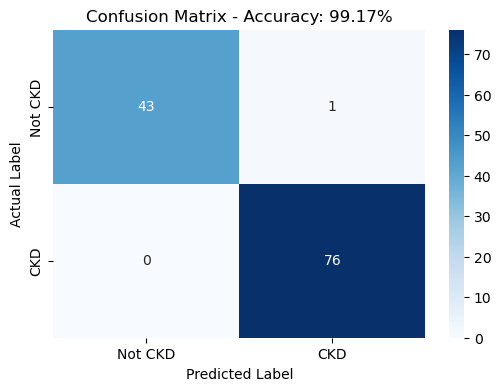

Classification Report:
              precision    recall  f1-score   support

     Not CKD       1.00      0.98      0.99        44
         CKD       0.99      1.00      0.99        76

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


rfmodel = RandomForestClassifier(n_estimators=100, random_state=42)
rfmodel.fit(X_train, y_train)


y_tstPred_rf = rfmodel.predict(X_test)
y_trnPred_rf = rfmodel.predict(X_train)

# Test the results
rf_acc = rfmodel.score(X_test, y_test)


print(f"Scaled Random Forest Accuracy: {rf_acc:.4f}\n")


#r^2
r2_train_rmodel= r2_score(y_train, y_trnPred_rf)
r2_test_rmodel = r2_score(y_test, y_tstPred_rf)

# Evaluate Random Forest
print('--- Random Forest ---')
print('MAE:', mean_absolute_error(y_test, y_tstPred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_tstPred_rf)))
print('R2 Train:', r2_train_rmodel)
print('R2 Test:', r2_test_rmodel)


print('\n')

#Confusion Matrix
print("="*50)

cm = confusion_matrix(y_test, y_tstPred_rf)
print("Confusion Matrix:")
print(cm)
print("="*50)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not CKD', 'CKD'],
            yticklabels=['Not CKD', 'CKD'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title(f'Confusion Matrix - Accuracy: {rf_acc*100:.2f}%')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_tstPred_rf, target_names=['Not CKD', 'CKD']))

CROSS-VALIDATION

In [16]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rfmodel, X, y, cv=5)

print("--- Cross-Validation Results ---")
print("Scores for each fold:", scores)
print(f"Mean Accuracy: {scores.mean():.4f}")

--- Cross-Validation Results ---
Scores for each fold: [0.9875 1.     0.9625 0.975  1.    ]
Mean Accuracy: 0.9850


RANDOM STATE EXPERIMENT

This is to generalize the model for each run to not always be stuck at 100% due to the random state. By running it over again, data would be scrambled and gives differnt data accuracy.

RANDOM STATE EXPERIMENT 1

Scaled Random Forest Accuracy: 0.9917

Classification Report :- 
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        52
           1       0.99      1.00      0.99        68

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120

--- Random Forest ---
MAE: 0.008333333333333333
RMSE: 0.09128709291752768
R2 Train: 1.0
R2 Test: 0.9660633484162896


Confusion Matrix:
[[51  1]
 [ 0 68]]


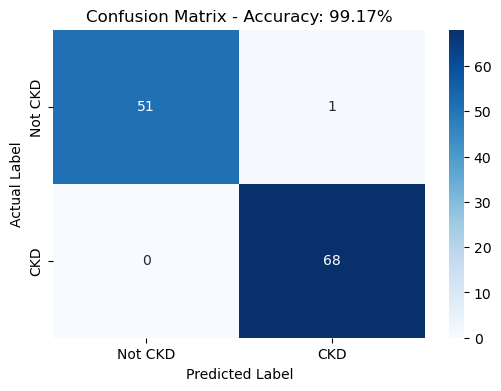

Classification Report:
              precision    recall  f1-score   support

     Not CKD       1.00      0.98      0.99        52
         CKD       0.99      1.00      0.99        68

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

rfmodel = RandomForestClassifier(n_estimators=100)
rfmodel.fit(X_train, y_train)

y_tstPred_rf = rfmodel.predict(X_test)
y_trnPred_rf = rfmodel.predict(X_train)

# Test the results
rf_acc = rfmodel.score(X_test, y_test)

print(f"Scaled Random Forest Accuracy: {rf_acc:.4f}\n")
print(f"Classification Report :- \n {classification_report(y_test, y_tstPred_rf)}")

#r^2
r2_train_rmodel= r2_score(y_train, y_trnPred_rf)
r2_test_rmodel = r2_score(y_test, y_tstPred_rf)

# Evaluate Random Forest
print('--- Random Forest ---')
print('MAE:', mean_absolute_error(y_test, y_tstPred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_tstPred_rf)))
print('R2 Train:', r2_train_rmodel)
print('R2 Test:', r2_test_rmodel)

print('\n')

#Confusion Matrix
print("="*50)

cm = confusion_matrix(y_test, y_tstPred_rf)
print("Confusion Matrix:")
print(cm)
print("="*50)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not CKD', 'CKD'],
            yticklabels=['Not CKD', 'CKD'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title(f'Confusion Matrix - Accuracy: {rf_acc*100:.2f}%')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_tstPred_rf, target_names=['Not CKD', 'CKD']))

RANDOM STATE EXPERIMENT 2


Scaled Random Forest Accuracy: 0.9833

Classification Report :- 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        77

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120

--- Random Forest ---
MAE: 0.016666666666666666
RMSE: 0.12909944487358055
R2 Train: 1.0
R2 Test: 0.9275143461189973


Confusion Matrix:
[[42  1]
 [ 1 76]]


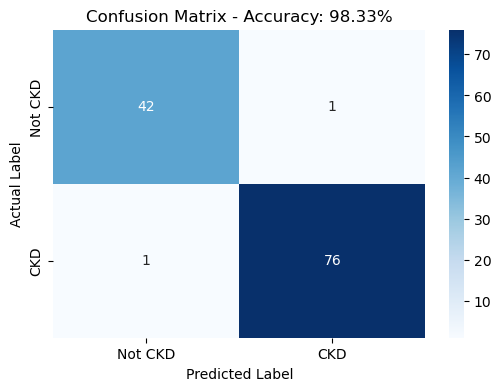

Classification Report:
              precision    recall  f1-score   support

     Not CKD       0.98      0.98      0.98        43
         CKD       0.99      0.99      0.99        77

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120



In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

rfmodel = RandomForestClassifier(n_estimators=100)
rfmodel.fit(X_train, y_train)

y_tstPred_rf = rfmodel.predict(X_test)
y_trnPred_rf = rfmodel.predict(X_train)

# Test the results
rf_acc = rfmodel.score(X_test, y_test)

print(f"Scaled Random Forest Accuracy: {rf_acc:.4f}\n")
print(f"Classification Report :- \n {classification_report(y_test, y_tstPred_rf)}")

#r^2
r2_train_rmodel= r2_score(y_train, y_trnPred_rf)
r2_test_rmodel = r2_score(y_test, y_tstPred_rf)

# Evaluate Random Forest
print('--- Random Forest ---')
print('MAE:', mean_absolute_error(y_test, y_tstPred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_tstPred_rf)))
print('R2 Train:', r2_train_rmodel)
print('R2 Test:', r2_test_rmodel)

print('\n')

#Confusion Matrix
print("="*50)

cm = confusion_matrix(y_test, y_tstPred_rf)
print("Confusion Matrix:")
print(cm)
print("="*50)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not CKD', 'CKD'],
            yticklabels=['Not CKD', 'CKD'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title(f'Confusion Matrix - Accuracy: {rf_acc*100:.2f}%')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_tstPred_rf, target_names=['Not CKD', 'CKD']))